In [9]:
import numpy as np
import matplotlib.pyplot as plt

In [10]:
def mse(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

In [11]:
def r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    return 1 - (ss_res / ss_tot)

Least Squares Line:   MSE = 0.0483411551240607  R2 = 0.0096336399688155
Polyfit degree 3:     MSE = 0.024369106693465932  R2 = 0.5007495490895477
Better fit (by MSE): Polynomial degree 3


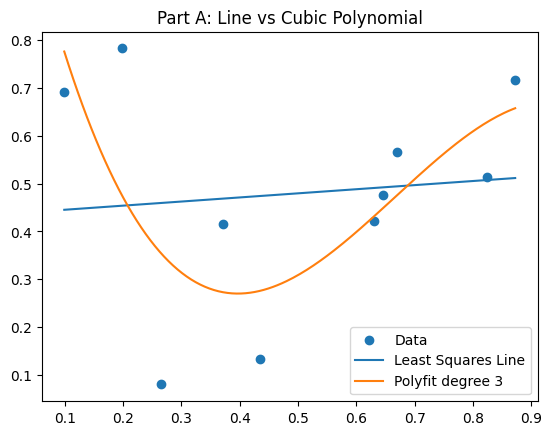

In [12]:
X = np.random.rand(10)
X = np.sort(X)
Y = np.random.rand(10)

A = np.vstack([X, np.ones(len(X))]).T
m, c = np.linalg.lstsq(A, Y, rcond=None)[0]

y_pred_line = m*X + c

coeffs_poly = np.polyfit(X, Y, 3)

y_pred_poly = np.polyval(coeffs_poly, X)

mse_line = mse(Y, y_pred_line)
r2_line = r2(Y, y_pred_line)

mse_poly = mse(Y, y_pred_poly)
r2_poly = r2(Y, y_pred_poly)

print("Least Squares Line:   MSE =", mse_line, " R2 =", r2_line)
print("Polyfit degree 3:     MSE =", mse_poly, " R2 =", r2_poly)

if mse_poly < mse_line:
    print("Better fit (by MSE): Polynomial degree 3")
else:
    print("Better fit (by MSE): Least Squares Line")

x_line = np.linspace(min(X), max(X), 200)
y_line = m*x_line + c
y_poly_line = np.polyval(coeffs_poly, x_line)

plt.scatter(X, Y, label="Data")
plt.plot(x_line, y_line, label="Least Squares Line")
plt.plot(x_line, y_poly_line, label="Polyfit degree 3")
plt.title("Part A: Line vs Cubic Polynomial")
plt.legend()
plt.show()

Degree 1 : MSE = 0.04834115512406071  R2 = 0.009633639968815388
Degree 2 : MSE = 0.028082652303086826  R2 = 0.4246700545311004
Degree 3 : MSE = 0.024369106693465932  R2 = 0.5007495490895477
Degree 4 : MSE = 0.023654397098324342  R2 = 0.515391821050224
Degree 5 : MSE = 0.019134077459538705  R2 = 0.6079997137526763
Degree 6 : MSE = 0.017502816443691095  R2 = 0.641419395809915
Degree 7 : MSE = 0.005959244683700395  R2 = 0.8779128167131024
Degree 8 : MSE = 3.15140319666533e-05  R2 = 0.9993543713002178
Degree 9 : MSE = 4.1359470827861785e-20  R2 = 1.0


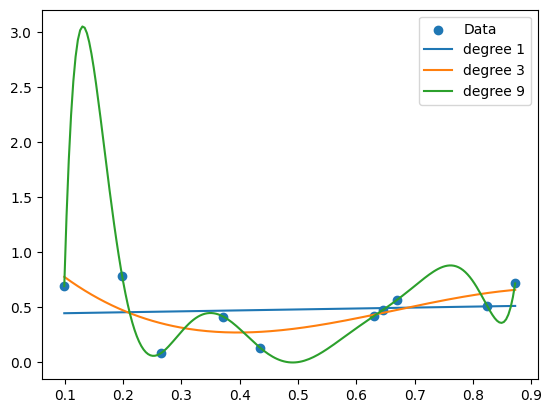

In [13]:
max_degree = min(9, len(X)-1)

for d in range(1, max_degree+1):
    coeffs = np.polyfit(X, Y, d)
    y_pred = np.polyval(coeffs, X)

    print("Degree", d, ": MSE =", mse(Y, y_pred), " R2 =", r2(Y, y_pred))

x_line = np.linspace(min(X), max(X), 200)

plt.scatter(X, Y, label="Data")

deg_list = [1, 3, max_degree]

for d in deg_list:
    coeffs = np.polyfit(X, Y, d)
    y_plot = np.polyval(coeffs, x_line)
    plt.plot(x_line, y_plot, label="degree " + str(d))

plt.legend()
plt.show()

Vandermonde degree 3: MSE = 0.024369106693465942  R2 = 0.5007495490895475


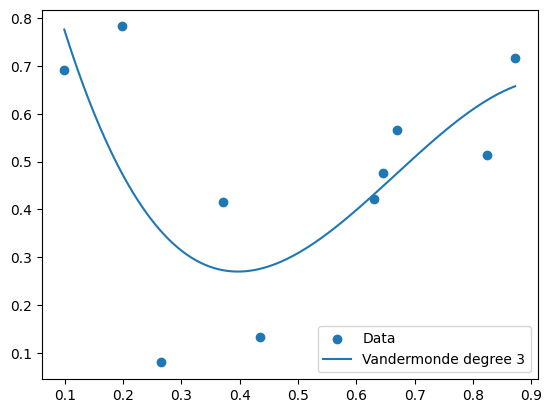

In [14]:
degree = 3

V = np.vander(X, degree+1)
coeffs_v = np.linalg.lstsq(V, Y, rcond=None)[0]

y_pred_v = np.dot(V, coeffs_v)
print("Vandermonde degree 3: MSE =", mse(Y, y_pred_v), " R2 =", r2(Y, y_pred_v))

V_line = np.vander(x_line, degree+1)
y_v_line = np.dot(V_line, coeffs_v)

plt.scatter(X, Y, label="Data")
plt.plot(x_line, y_v_line, label="Vandermonde degree 3")
plt.legend()
plt.show()